In [27]:
#importando as bibliotecas que serão usadas durante o código

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Criando uma conexão com o banco de dados SQLite

conexao = sqlite3.connect('dados_vendas.db')

# Permitindo executar comandos SQL
cursor = conexao.cursor()

# Tabela de vendas
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

# Dados de vendas na tabela
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00)
''')

# Confirmando as alterações no banco
conexao.commit()



In [28]:
# Utilizando o Pandas para executar uma consulta SQL e carregando os dados diretamente para um DateFrame


df_vendas = pd.read_sql_query(
    "SELECT * FROM vendas1",
    conexao
)


df_vendas

# Informações gerais

print("\nInformações do DataFrame:")
df_vendas.info()

# Verificando a quantidade de linhas e colunas

print("\nQuantidade de linhas e colunas:")
print(df_vendas.shape)

# Verificando se existem valores ausentes

print("\nValores ausentes:")
print(df_vendas.isnull().sum())

# Estatísticas básicas das vendas

df_vendas.describe()




Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     28 non-null     int64  
 1   data_venda   28 non-null     object 
 2   produto      28 non-null     object 
 3   categoria    28 non-null     object 
 4   valor_venda  28 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 1.2+ KB

Quantidade de linhas e colunas:
(28, 5)

Valores ausentes:
id_venda       0
data_venda     0
produto        0
categoria      0
valor_venda    0
dtype: int64


,id_venda,valor_venda
count,28.000000,28.000000
mean,14.500000,628.571429
std,8.225975,399.867703
min,1.000000,150.000000
25%,7.750000,300.000000
50%,14.500000,525.000000
75%,21.250000,900.000000
max,28.000000,1500.000000


In [47]:
# Convertendo a coluna de data para o formato datetime

df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

# Criando uma coluna com o mês da venda

df_vendas['mes'] = df_vendas['data_venda'].dt.month

# Criando uma coluna com o nome do mês

df_vendas['nome_mes'] = df_vendas['data_venda'].dt.month_name()

# Exibindo o resultado

df_vendas.head()

,id_venda,data_venda,produto,categoria,valor_venda,mes,nome_mes
0,1,2023-01-01,Produto A,Eletrônicos,1500.0,1,January
1,2,2023-01-05,Produto B,Roupas,350.0,1,January
2,3,2023-02-10,Produto C,Eletrônicos,1200.0,2,February
3,4,2023-03-15,Produto D,Livros,200.0,3,March
4,5,2023-03-20,Produto E,Eletrônicos,800.0,3,March


In [31]:
# Valor médio de cada venda

media_vendas = df_vendas['valor_venda'].mean()

print(f"Valor médio por venda: R$ {media_vendas:,.2f}")

# Maior valor de venda

maior_venda = df_vendas['valor_venda'].max()

# Menor valor de venda

menor_venda = df_vendas['valor_venda'].min()

print(f"Maior venda: R$ {maior_venda:,.2f}")
print(f"Menor venda: R$ {menor_venda:,.2f}")


Valor médio por venda: R$ 628.57
Maior venda: R$ 1,500.00
Menor venda: R$ 150.00


In [32]:
# Agrupando o faturamento por mês

vendas_mes = df_vendas.groupby('mes')['valor_venda'].sum()

print(vendas_mes)

mes
1     3700.0
2     2400.0
3     2000.0
4      800.0
5      300.0
6     2000.0
7     1200.0
8     1400.0
9      600.0
10     900.0
11    1800.0
12     500.0
Name: valor_venda, dtype: float64


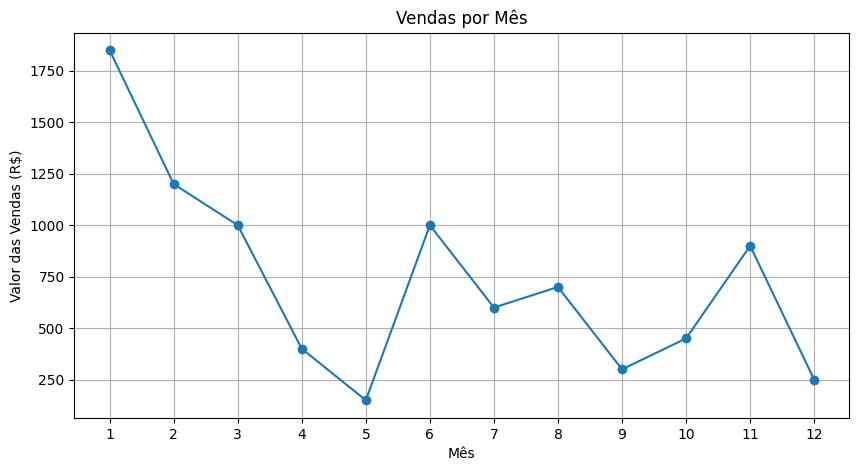

In [20]:
#   Gráfico de linha com as vendas mensais

plt.figure(figsize=(10, 5))

plt.plot(
    vendas_mes.index,
    vendas_mes.values,
    marker='o'
)

plt.title('Vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Valor das Vendas (R$)')

plt.xticks(range(1, 13))

plt.grid(True)

plt.show()

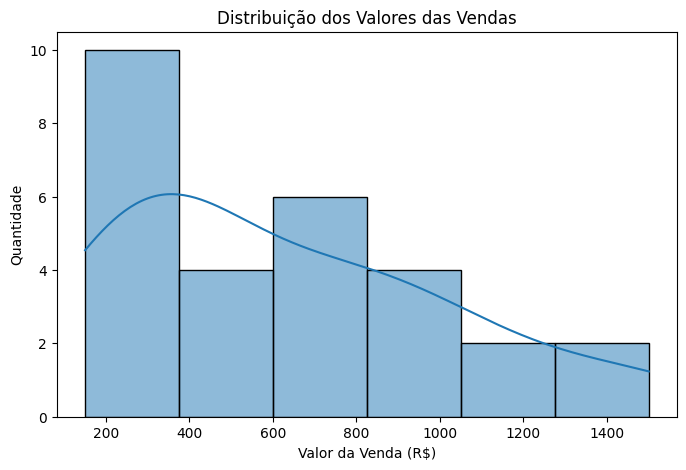

In [33]:
# Gráfico de distribuição dos valores das vendas

plt.figure(figsize=(8, 5))

sns.histplot(
    df_vendas['valor_venda'],
    bins=6,
    kde=True
)

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor da Venda (R$)')
plt.ylabel('Quantidade')

plt.show()